In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete")


Matplotlib is building the font cache; this may take a moment.


Setup complete


In [2]:
carbon_df = pd.read_parquet(DATA_RAW / "carbon_intensity_GB_2021_2024.parquet")
carbon_df["from"] = pd.to_datetime(carbon_df["from"], utc=True)
carbon_df = carbon_df.sort_values("from").reset_index(drop=True)
print("Carbon intensity shape:", carbon_df.shape)
print(carbon_df.dtypes)
carbon_df.head()

Carbon intensity shape: (48237, 5)
from        datetime64[ns, UTC]
to          datetime64[ns, UTC]
forecast                  int64
actual                  float64
index                    object
dtype: object


,from,to,forecast,actual,index
0,2020-12-31 23:30:00+00:00,2021-01-01 00:00:00+00:00,190,184.0,moderate
1,2021-01-01 00:00:00+00:00,2021-01-01 00:30:00+00:00,181,187.0,moderate
2,2021-01-01 00:30:00+00:00,2021-01-01 01:00:00+00:00,178,182.0,moderate
3,2021-01-01 01:00:00+00:00,2021-01-01 01:30:00+00:00,175,178.0,moderate
4,2021-01-01 01:30:00+00:00,2021-01-01 02:00:00+00:00,174,171.0,moderate


In [3]:
gen_df = pd.read_parquet(DATA_RAW / "generation_GB_2021_2024.parquet")
load_df = pd.read_parquet(DATA_RAW / "load_GB_2021_2024.parquet")
print("Generation shape:", gen_df.shape)
print("Load shape:", load_df.shape)
gen_df.head()

Generation shape: (7890, 11)
Load shape: (7886, 1)


,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2021-01-01 00:00:00+00:00,3116.0,11268.0,0.0,0.0,0.0,385.0,5949.0,191.0,0.0,1588.65,3146.04
2021-01-01 00:30:00+00:00,3118.0,11526.0,0.0,0.0,0.0,382.0,5956.0,187.0,1.0,1451.37,3072.82
2021-01-01 01:00:00+00:00,3087.0,11240.0,0.0,0.0,0.0,349.0,5948.0,186.0,1.0,1403.17,3019.87
2021-01-01 01:30:00+00:00,3117.0,10365.0,0.0,0.0,0.0,334.0,5950.0,187.0,0.0,1425.04,2884.78
2021-01-01 02:00:00+00:00,3113.0,10020.0,0.0,0.0,0.0,330.0,5949.0,187.0,0.0,1487.91,2818.44


In [4]:
print("Carbon intensity - missing values:")
print(carbon_df.isnull().sum())
print("\nBasic stats:")
print(carbon_df[["forecast", "actual"]].describe())

Carbon intensity - missing values:
from          0
to            0
forecast      0
actual      187
index         0
dtype: int64

Basic stats:
           forecast        actual
count  48237.000000  48050.000000
mean     173.079545    175.013174
std       63.939642     63.824797
min       23.000000      0.000000
25%      123.000000    125.000000
50%      178.000000    181.000000
75%      224.000000    226.000000
max      380.000000    345.000000


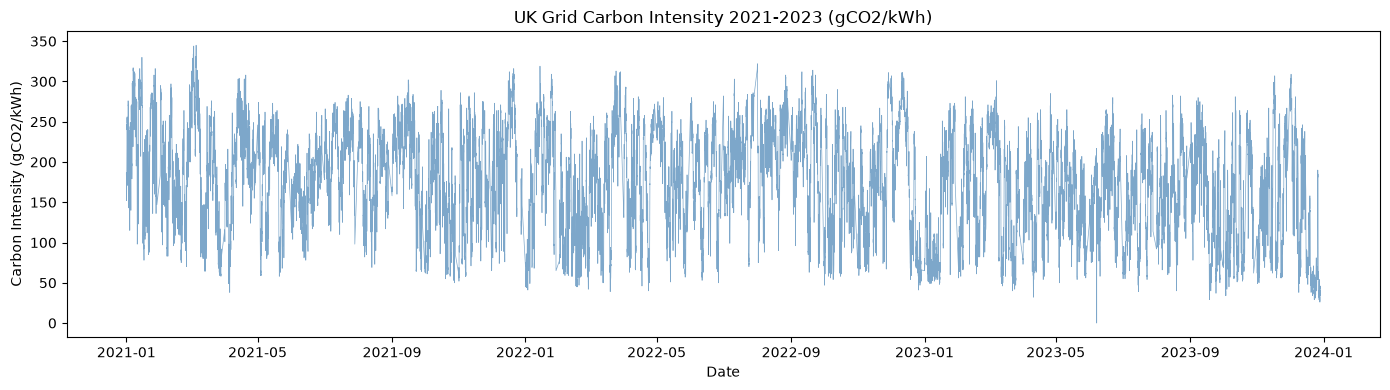

Plot saved


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(carbon_df["from"], carbon_df["actual"], 
        linewidth=0.5, alpha=0.7, color="steelblue")
ax.set_title("UK Grid Carbon Intensity 2021-2023 (gCO2/kWh)")
ax.set_xlabel("Date")
ax.set_ylabel("Carbon Intensity (gCO2/kWh)")
plt.tight_layout()
plt.savefig(FIGURES / "carbon_intensity_timeseries.png", dpi=150)
plt.show()
print("Plot saved")

In [6]:
# Run once elexon_fuelinst_2021_2023.parquet exists
from pathlib import Path
elexon_path = Path("../data/raw/elexon_fuelinst_2021_2023.parquet")
if elexon_path.exists():
    elexon_df = pd.read_parquet(elexon_path)
    print("Elexon shape:", elexon_df.shape)
    print(elexon_df["fuelType"].value_counts())
else:
    print("Elexon not ready yet - rerun once download completes")

Elexon not ready yet - rerun once download completes
